In [1]:
# ── Small-Worldness Notebook ──────────────────────────────────
# Cell 1 — Imports + Config + Load + Recompute connectivity

import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import os
import warnings
from collections import defaultdict
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────
FIG_DIR = r'D:\Data science Project\EEG Chrononet\EEGdata\figures'
os.makedirs(FIG_DIR, exist_ok=True)

mpl.rcParams.update({
    'font.size'        : 14,
    'font.weight'      : 'bold',
    'axes.titlesize'   : 16,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 14,
    'axes.labelweight' : 'bold',
    'xtick.labelsize'  : 12,
    'ytick.labelsize'  : 12,
    'legend.fontsize'  : 12,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

def save_fig(fname, dpi=300):
    path = os.path.join(FIG_DIR, fname)
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f"Saved: {path}")

# ── Config ────────────────────────────────────────────────────
BASE     = r'D:\Data science Project\EEG Chrononet\EEGdata\Data\CleanData'
CHANNELS = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
SFREQ    = 128
BANDS    = {
    'delta': (1,  4),
    'theta': (4,  8),
    'alpha': (8,  13),
    'beta' : (13, 30),
    'gamma': (30, 45),
}
BAND_NAMES = list(BANDS.keys())

MANIFEST = [
    ('NDS001','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS001_Music_CD.mat')),
    ('NDS001','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS001_Rest_CD.mat')),
    ('NDS002','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS002_Music_CD.mat')),
    ('NDS002','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS002_Rest_CD.mat')),
    ('NDS003','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS003_Music_CD.mat')),
    ('NDS003','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS003_Rest_CD.mat')),
    ('NDS004','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS004_Music_CD.mat')),
    ('NDS004','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS004_Rest_CD.mat')),
    ('NDS005','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS005_Music_CD.mat')),
    ('NDS005','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS005_Rest_CD.mat')),
    ('NDS006','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS006_Music_CD.mat')),
    ('NDS006','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS006_Rest_CD.mat')),
    ('NDS007','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS007_Music_CD.mat')),
    ('NDS007','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS007_Rest_CD.mat')),
    ('CGS01','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS01_Music_CD.mat')),
    ('CGS01','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS01_Rest_CD.mat')),
    ('CGS02','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS02_Music_CD.mat')),
    ('CGS02','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS02_Rest_CD.mat')),
    ('CGS03','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS03_Music_CD.mat')),
    ('CGS03','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS03_Rest_CD.mat')),
    ('CGS04','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS04_Music_CD.mat')),
    ('CGS04','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS04_Rest_CD.mat')),
    ('CGS05','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS05_Music_CD.mat')),
    ('CGS05','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS05_Rest_CD.mat')),
    ('CGS06','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS06_Music_CD.mat')),
    ('CGS06','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS06_Rest_CD.mat')),
    ('CGS07','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS07_Music_CD.mat')),
    ('CGS07','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS07_Rest_CD.mat')),
]

# ── Load data ─────────────────────────────────────────────────
data = {}
for subj, group, cond, fpath in MANIFEST:
    mat = sio.loadmat(fpath)
    data[(subj,cond)] = {
        'eeg'  : mat['clean_data'].astype(np.float32),
        'group': group, 'subj': subj, 'cond': cond
    }

print(f"Loaded {len(data)} recordings ✅")
print(f"NetworkX version: {nx.__version__}")

Loaded 28 recordings ✅
NetworkX version: 3.4.2


In [3]:
# Cell 2 — Compute full 91-pair MSC connectivity for all subjects
from scipy.signal import coherence as scipy_coherence

print("Computing connectivity matrices (takes ~5 min)...")

conn_subj = defaultdict(lambda: defaultdict(lambda: {}))

for subj, group, cond, _ in MANIFEST:
    eeg = data[(subj,cond)]['eeg'].astype(np.float64)
    for bname, (flo, fhi) in BANDS.items():
        mat = np.zeros((14, 14))
        for i in range(14):
            for j in range(i+1, 14):
                s1 = np.clip(eeg[i], -5*eeg[i].std(), 5*eeg[i].std())
                s2 = np.clip(eeg[j], -5*eeg[j].std(), 5*eeg[j].std())
                f, Cxy = scipy_coherence(s1, s2, fs=SFREQ, nperseg=256)
                mask   = (f >= flo) & (f < fhi)
                val    = Cxy[mask].mean()
                mat[i,j] = val
                mat[j,i] = val
        conn_subj[subj][cond][bname] = mat
    print(f"  {subj} {cond} done")

print("\n✅ Connectivity done")

Computing connectivity matrices (takes ~5 min)...
  NDS001 Music done
  NDS001 Rest done
  NDS002 Music done
  NDS002 Rest done
  NDS003 Music done
  NDS003 Rest done
  NDS004 Music done
  NDS004 Rest done
  NDS005 Music done
  NDS005 Rest done
  NDS006 Music done
  NDS006 Rest done
  NDS007 Music done
  NDS007 Rest done
  CGS01 Music done
  CGS01 Rest done
  CGS02 Music done
  CGS02 Rest done
  CGS03 Music done
  CGS03 Rest done
  CGS04 Music done
  CGS04 Rest done
  CGS05 Music done
  CGS05 Rest done
  CGS06 Music done
  CGS06 Rest done
  CGS07 Music done
  CGS07 Rest done

✅ Connectivity done


In [5]:
# Cell 3 — Small-worldness on thresholded networks

def threshold_matrix(mat, density=0.25):
    mat = np.abs(mat.copy())
    np.fill_diagonal(mat, 0)
    thresh = np.percentile(mat[mat > 0], (1 - density) * 100)
    mat_t  = mat.copy()
    mat_t[mat_t < thresh] = 0
    return mat_t

def small_worldness(mat, density=0.25, n_rand=50):
    mat_t = threshold_matrix(mat, density)
    G     = nx.from_numpy_array(mat_t)
    G.remove_nodes_from(list(nx.isolates(G)))
    if G.number_of_nodes() < 4:
        return np.nan

    C_real = nx.average_clustering(G, weight='weight')
    try:
        L_real = nx.average_shortest_path_length(G, weight='weight')
    except Exception:
        return np.nan
    if not np.isfinite(L_real) or L_real == 0:
        return np.nan

    C_rands, L_rands = [], []
    for _ in range(n_rand):
        try:
            G_r = nx.random_reference(G, niter=3, connectivity=False)
            G_r.remove_nodes_from(list(nx.isolates(G_r)))
            if G_r.number_of_nodes() < 4:
                continue
            C_rands.append(nx.average_clustering(G_r, weight='weight'))
            L_rands.append(nx.average_shortest_path_length(G_r, weight='weight'))
        except Exception:
            continue

    if len(C_rands) < 5:
        return np.nan

    C_rand = np.nanmean(C_rands)
    L_rand = np.nanmean(L_rands)
    if C_rand == 0 or L_rand == 0:
        return np.nan

    return (C_real / C_rand) / (L_real / L_rand)

# ── Run ───────────────────────────────────────────────────────
DENSITY = 0.25
print(f"Computing small-worldness (density={DENSITY}, n_rand=50)")
print("Expected time: ~8-12 minutes\n")

sw_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

total = len(MANIFEST) * len(BAND_NAMES)
done  = 0

for subj, group, cond, _ in MANIFEST:
    for bname in BAND_NAMES:
        mat   = conn_subj[subj][cond][bname].copy()
        sigma = small_worldness(mat, density=DENSITY, n_rand=50)
        sw_results[group][cond][bname].append(sigma)
        done += 1
        val_str = f"{sigma:.4f}" if np.isfinite(sigma) else "NaN"
        print(f"  [{done:3d}/{total}] {subj:8s} {cond:5s} {bname:6s}  σ={val_str}",
              flush=True)

print("\n✅ Small-worldness done")

Computing small-worldness (density=0.25, n_rand=50)
Expected time: ~8-12 minutes

  [  1/140] NDS001   Music delta   σ=1.5047
  [  2/140] NDS001   Music theta   σ=1.7012
  [  3/140] NDS001   Music alpha   σ=1.3514
  [  4/140] NDS001   Music beta    σ=2.3355
  [  5/140] NDS001   Music gamma   σ=1.0691
  [  6/140] NDS001   Rest  delta   σ=1.6525
  [  7/140] NDS001   Rest  theta   σ=1.4101
  [  8/140] NDS001   Rest  alpha   σ=1.1404
  [  9/140] NDS001   Rest  beta    σ=1.5915
  [ 10/140] NDS001   Rest  gamma   σ=NaN
  [ 11/140] NDS002   Music delta   σ=1.3599
  [ 12/140] NDS002   Music theta   σ=1.3306
  [ 13/140] NDS002   Music alpha   σ=1.3356
  [ 14/140] NDS002   Music beta    σ=NaN
  [ 15/140] NDS002   Music gamma   σ=2.8763
  [ 16/140] NDS002   Rest  delta   σ=1.0899
  [ 17/140] NDS002   Rest  theta   σ=1.6264
  [ 18/140] NDS002   Rest  alpha   σ=1.3700
  [ 19/140] NDS002   Rest  beta    σ=NaN
  [ 20/140] NDS002   Rest  gamma   σ=4.4614
  [ 21/140] NDS003   Music delta   σ=2.1924
  [

Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_small_worldness.png


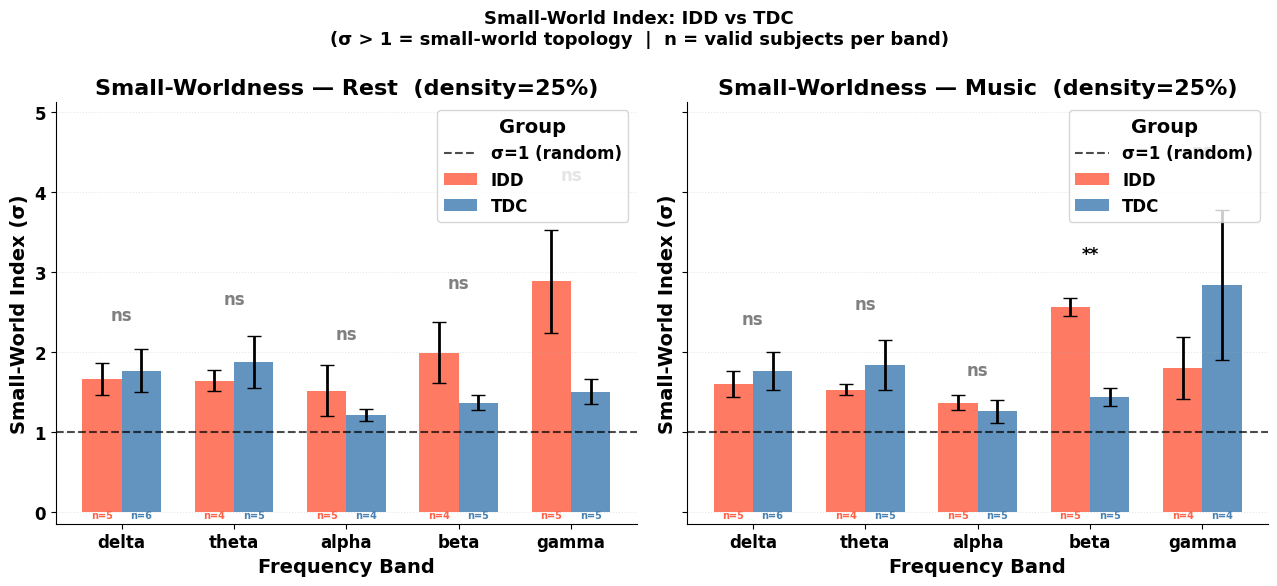

In [7]:
# Cell 4 — Plot small-worldness

from scipy.stats import mannwhitneyu

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
x     = np.arange(len(BAND_NAMES))
width = 0.35

for ax, cond in zip(axes, ['Rest', 'Music']):
    for offset, (group, color) in enumerate(
            [('IDD','tomato'),('TDC','steelblue')]):
        means, sems = [], []
        for bname in BAND_NAMES:
            vals = np.array(sw_results[group][cond][bname])
            vals = vals[np.isfinite(vals)]
            means.append(np.mean(vals)               if len(vals) > 0 else np.nan)
            sems.append(np.std(vals)/np.sqrt(len(vals)) if len(vals) > 1 else 0)

        ax.bar(x + offset*width, means, width,
               label=group, color=color, alpha=0.85,
               yerr=sems, capsize=5, error_kw={'linewidth':2})

    # sigma=1 reference
    ax.axhline(1.0, color='black', linewidth=1.5,
               linestyle='--', alpha=0.7, label='σ=1 (random)')

    # Significance + n valid label
    all_tops = []
    for bi, bname in enumerate(BAND_NAMES):
        idd_v = np.array(sw_results['IDD'][cond][bname])
        tdc_v = np.array(sw_results['TDC'][cond][bname])
        idd_v = idd_v[np.isfinite(idd_v)]
        tdc_v = tdc_v[np.isfinite(tdc_v)]

        n_idd = len(idd_v)
        n_tdc = len(tdc_v)

        if n_idd < 3 or n_tdc < 3:
            star = 'ns'
        else:
            _, p = mannwhitneyu(idd_v, tdc_v, alternative='two-sided')
            if   p < 0.001: star = '***'
            elif p < 0.01:  star = '**'
            elif p < 0.05:  star = '*'
            else:           star = 'ns'

        idd_top = np.nanmean(idd_v) + np.nanstd(idd_v)/np.sqrt(n_idd) if n_idd>0 else 0
        tdc_top = np.nanmean(tdc_v) + np.nanstd(tdc_v)/np.sqrt(n_tdc) if n_tdc>0 else 0
        y_top   = max(idd_top, tdc_top) * 1.18
        all_tops.append(y_top)

        ax.text(bi + width/2, y_top, star,
                ha='center', fontsize=12, fontweight='bold',
                color='black' if star != 'ns' else 'gray')

        # n valid below bars
        ax.text(bi,           -0.08, f'n={n_idd}', ha='center',
                fontsize=7, color='tomato')
        ax.text(bi + width,   -0.08, f'n={n_tdc}', ha='center',
                fontsize=7, color='steelblue')

    ax.set_ylim(-0.15, max(all_tops) * 1.15)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(BAND_NAMES)
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('Small-World Index (σ)')
    ax.set_title(f'Small-Worldness — {cond}  (density=25%)')
    ax.legend(title='Group', loc='upper right')
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')

plt.suptitle('Small-World Index: IDD vs TDC\n'
             '(σ > 1 = small-world topology  |  n = valid subjects per band)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fig_small_worldness.png', dpi=300)
plt.show()

  density=0.15 IDD Music beta: n=1 mean=3.372
  density=0.20 IDD Music beta: n=4 mean=3.617
  density=0.25 IDD Music beta: n=5 mean=2.774
  density=0.30 IDD Music beta: n=7 mean=2.189
  density=0.35 IDD Music beta: n=7 mean=2.039
  density=0.40 IDD Music beta: n=7 mean=1.937
  density=0.15 TDC Music beta: n=4 mean=2.137
  density=0.20 TDC Music beta: n=5 mean=1.530
  density=0.25 TDC Music beta: n=5 mean=1.452
  density=0.30 TDC Music beta: n=6 mean=1.326
  density=0.35 TDC Music beta: n=5 mean=1.309
  density=0.40 TDC Music beta: n=7 mean=1.229
Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_small_worldness_advanced.png


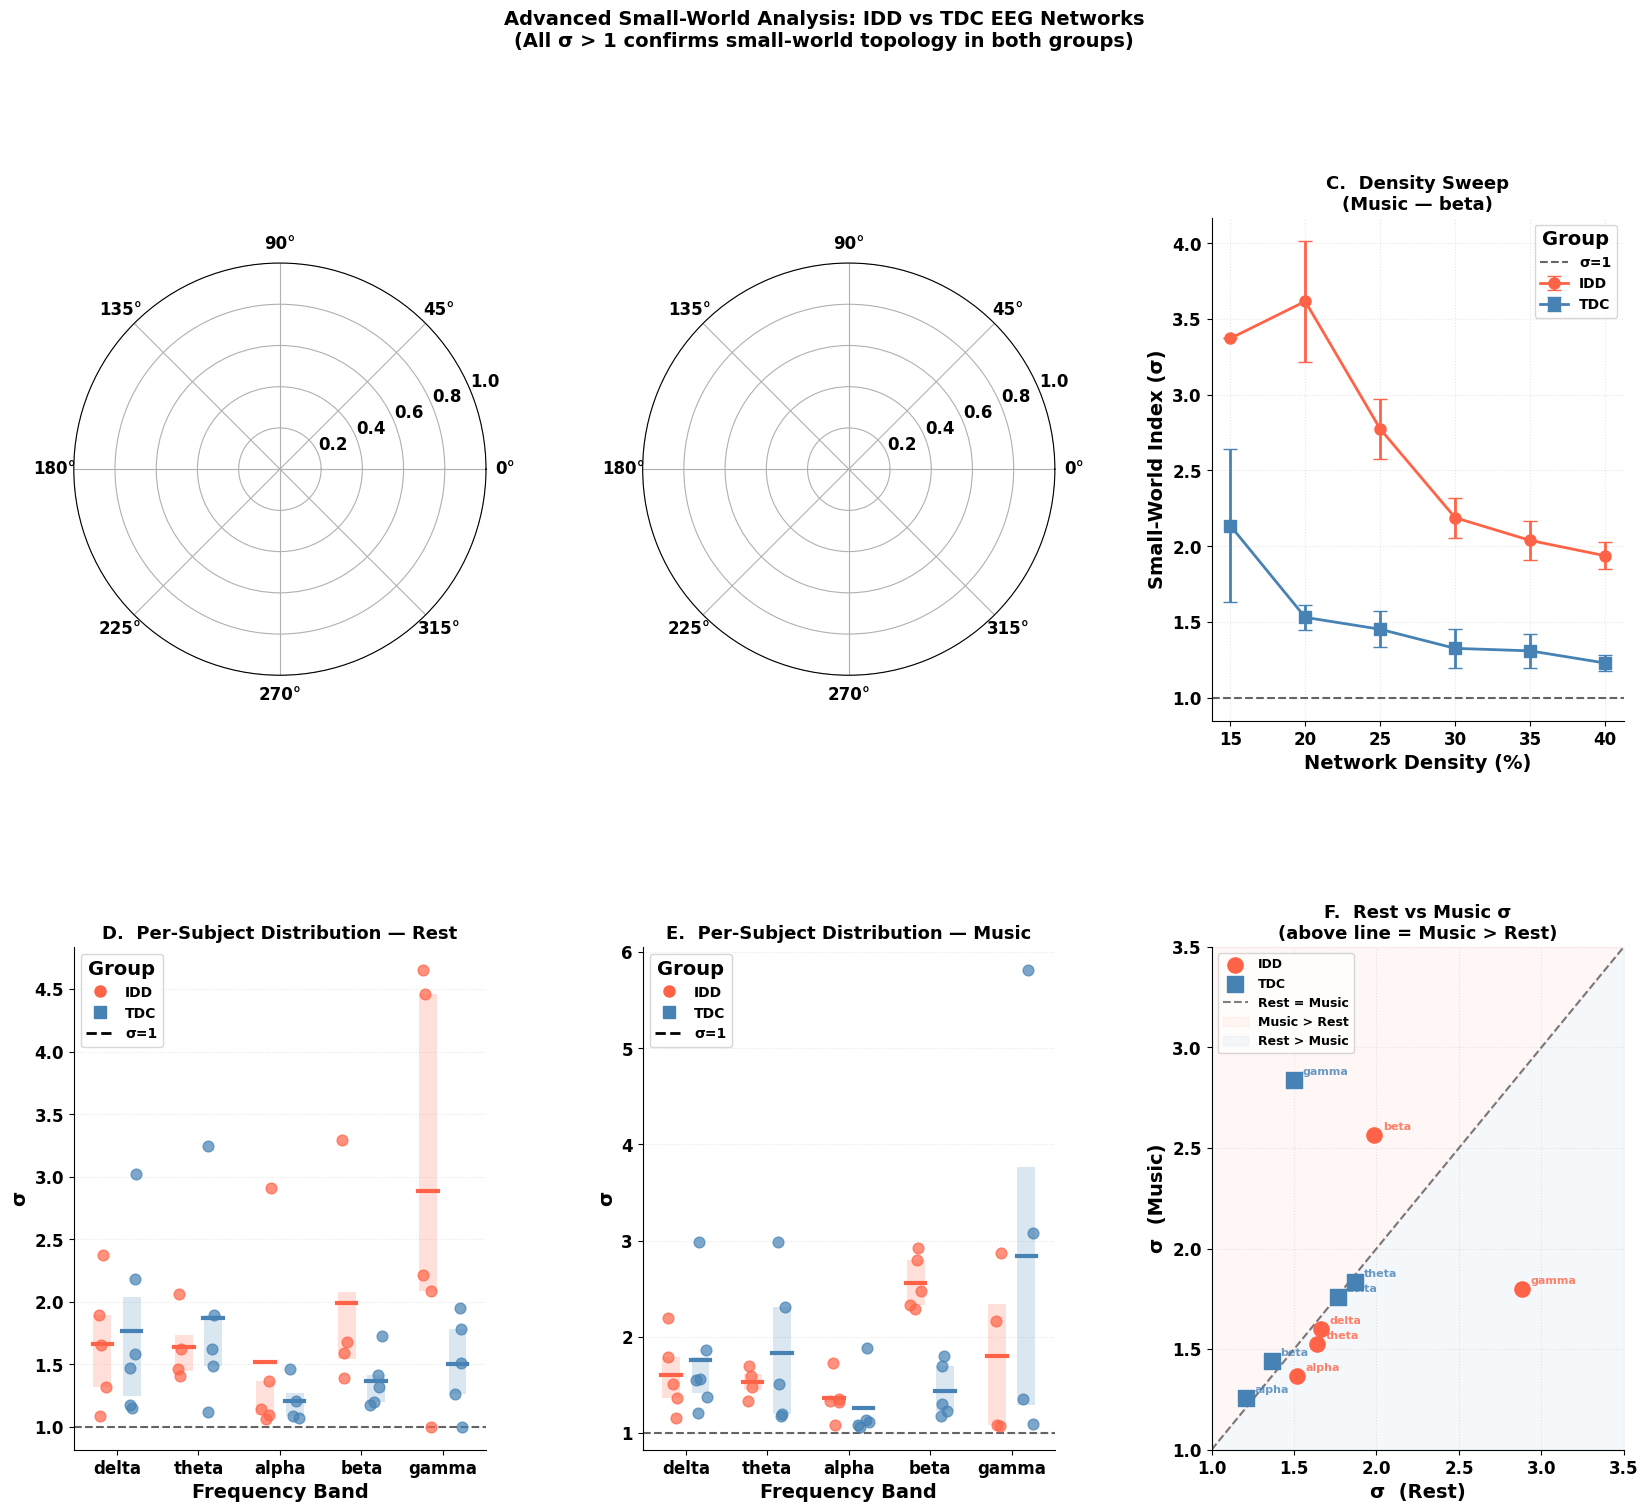

In [13]:
# Cell 5 — Advanced small-worldness visualization

from scipy.stats import mannwhitneyu
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Panel A: Radar chart (Rest) ───────────────────────────────
ax_radar_r = fig.add_subplot(gs[0, 0], projection='polar')
ax_radar_m = fig.add_subplot(gs[0, 1], projection='polar')

def radar_chart(ax, cond, title):
    N      = len(BAND_NAMES)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    for group, color, ls in [('IDD','tomato','-'),('TDC','steelblue','--')]:
        means = []
        for bname in BAND_NAMES:
            vals = np.array(sw_results[group][cond][bname])
            vals = vals[np.isfinite(vals)]
            means.append(np.mean(vals) if len(vals) > 0 else 1.0)
        means += means[:1]

        ax.plot(angles, means, color=color, ls=ls,
                linewidth=2.5, label=group, marker='o', markersize=6)
        ax.fill(angles, means, color=color, alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(BAND_NAMES, fontsize=12, fontweight='bold')
    ax.set_rlim(0, 3.5)                       # <-- use set_rlim for polar
    ax.set_rticks([1, 2, 3])
    ax.set_yticklabels(['1','2','3'], fontsize=9, color='gray')
    ax.set_rlabel_position(80)                # move radial labels off the data
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
              fontsize=10, title='Group')
    # sigma=1 reference circle
    theta_circle = np.linspace(0, 2*np.pi, 100)
    ax.plot(theta_circle, np.ones(100), 'k:', linewidth=1.5, alpha=0.6)
# ── Panel C: Density sweep ────────────────────────────────────
ax_density = fig.add_subplot(gs[0, 2])

DENSITIES  = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
focus_band = 'beta'
focus_cond = 'Music'

for group, color, marker in [('IDD','tomato','o'),('TDC','steelblue','s')]:
    sweep_means, sweep_sems = [], []
    for d in DENSITIES:
        vals_d = []
        for subj, grp, cond, _ in MANIFEST:
            if grp != group or cond != focus_cond:
                continue
            mat   = conn_subj[subj][cond][focus_band].copy()
            sigma = small_worldness(mat, density=d, n_rand=30)
            if np.isfinite(sigma):
                vals_d.append(sigma)
        sweep_means.append(np.mean(vals_d) if vals_d else np.nan)
        sweep_sems.append(np.std(vals_d)/np.sqrt(len(vals_d)) if len(vals_d)>1 else 0)
        print(f"  density={d:.2f} {group} {focus_cond} {focus_band}: "
              f"n={len(vals_d)} mean={sweep_means[-1]:.3f}", flush=True)

    ax_density.errorbar([d*100 for d in DENSITIES], sweep_means,
                        yerr=sweep_sems, color=color, marker=marker,
                        linewidth=2, markersize=8, capsize=5,
                        label=group)

ax_density.axhline(1.0, color='black', linewidth=1.5,
                   linestyle='--', alpha=0.6, label='σ=1')
ax_density.set_xlabel('Network Density (%)')
ax_density.set_ylabel('Small-World Index (σ)')
ax_density.set_title(f'C.  Density Sweep\n({focus_cond} — {focus_band})',
                     fontsize=13)
ax_density.legend(title='Group', fontsize=10)
ax_density.grid(True, alpha=0.3, linestyle=':')
ax_density.set_xticks([d*100 for d in DENSITIES])

# ── Panel D & E: Per-subject stripplot ───────────────────────
for col, cond in enumerate(['Rest','Music']):
    ax = fig.add_subplot(gs[1, col])

    x_positions = np.arange(len(BAND_NAMES))
    jitter = 0.08

    for bi, bname in enumerate(BAND_NAMES):
        for group, color, offset in [('IDD','tomato',-0.18),
                                      ('TDC','steelblue', 0.18)]:
            vals = np.array(sw_results[group][cond][bname])
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                continue

            # Individual points
            jit = np.random.uniform(-jitter, jitter, len(vals))
            ax.scatter(np.full(len(vals), bi+offset) + jit,
                       vals, color=color, alpha=0.7,
                       s=60, zorder=3)

            # Mean line
            ax.plot([bi+offset-0.12, bi+offset+0.12],
                    [np.mean(vals), np.mean(vals)],
                    color=color, linewidth=3, zorder=4)

            # IQR box
            q25, q75 = np.percentile(vals, [25, 75])
            ax.bar(bi+offset, q75-q25, 0.22,
                   bottom=q25, color=color, alpha=0.2,
                   zorder=2)

    ax.axhline(1.0, color='black', linewidth=1.5,
               linestyle='--', alpha=0.6)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(BAND_NAMES)
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('σ')
    ax.set_title(f'{"D" if cond=="Rest" else "E"}.  '
                 f'Per-Subject Distribution — {cond}',
                 fontsize=13)
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')

    # Legend
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0],[0], color='tomato',    marker='o', linewidth=0,
               markersize=8, label='IDD'),
        Line2D([0],[0], color='steelblue', marker='s', linewidth=0,
               markersize=8, label='TDC'),
        Line2D([0],[0], color='black', linewidth=2,
               linestyle='--', label='σ=1'),
    ]
    ax.legend(handles=handles, fontsize=10, title='Group')

# ── Panel F: Condition comparison (Rest vs Music per group) ───
ax_cond = fig.add_subplot(gs[1, 2])

for group, color, marker in [('IDD','tomato','o'),('TDC','steelblue','s')]:
    rest_means, music_means = [], []
    for bname in BAND_NAMES:
        r_vals = np.array(sw_results[group]['Rest'][bname])
        m_vals = np.array(sw_results[group]['Music'][bname])
        rest_means.append(np.nanmean(r_vals[np.isfinite(r_vals)]))
        music_means.append(np.nanmean(m_vals[np.isfinite(m_vals)]))

    ax_cond.scatter(rest_means, music_means,
                    color=color, marker=marker, s=120,
                    label=group, zorder=3)
    for bi, bname in enumerate(BAND_NAMES):
        ax_cond.annotate(bname,
                         (rest_means[bi], music_means[bi]),
                         textcoords='offset points',
                         xytext=(6, 4), fontsize=8,
                         color=color, alpha=0.8)

# Identity line
lims = [1.0, 3.5]
ax_cond.plot(lims, lims, 'k--', linewidth=1.5,
             alpha=0.5, label='Rest = Music')
ax_cond.fill_between(lims, lims, [3.5,3.5],
                     alpha=0.05, color='tomato',
                     label='Music > Rest')
ax_cond.fill_between(lims, [1.0,1.0], lims,
                     alpha=0.05, color='steelblue',
                     label='Rest > Music')
ax_cond.set_xlabel('σ  (Rest)')
ax_cond.set_ylabel('σ  (Music)')
ax_cond.set_title('F.  Rest vs Music σ\n(above line = Music > Rest)',
                  fontsize=13)
ax_cond.legend(fontsize=9)
ax_cond.grid(True, alpha=0.3, linestyle=':')
ax_cond.set_xlim(1.0, 3.5)
ax_cond.set_ylim(1.0, 3.5)

plt.suptitle('Advanced Small-World Analysis: IDD vs TDC EEG Networks\n'
             '(All σ > 1 confirms small-world topology in both groups)',
             fontsize=14, fontweight='bold', y=1.01)

save_fig('fig_small_worldness_advanced.png', dpi=300)
plt.show()

In [15]:
import pandas as pd
import os

# Find QualitativeData.xlsx
for root, dirs, files in os.walk(r'D:\Data science Project\EEG Chrononet\EEGdata'):
    for f in files:
        if 'qualitative' in f.lower() or 'QualitativeData' in f:
            path = os.path.join(root, f)
            print(f"Found: {path}\n")
            xl = pd.ExcelFile(path)
            print(f"Sheet names: {xl.sheet_names}\n")
            for sheet in xl.sheet_names:
                df = pd.read_excel(path, sheet_name=sheet)
                print(f"--- Sheet: {sheet} ---")
                print(f"Shape: {df.shape}")
                print(f"Columns: {list(df.columns)}")
                print(df.head(10).to_string())
                print()

Found: D:\Data science Project\EEG Chrononet\EEGdata\Data\QualitativeData.xlsx

Sheet names: ['Sheet1']

--- Sheet: Sheet1 ---
Shape: (7, 6)
Columns: ['Participant ID', 'Age     (in years)', 'IQ', 'SQ', 'Music perception', 'Facial expression']
  Participant ID  Age     (in years)  IQ  SQ Music perception Facial expression
0         NDS001                  28  68  60          Enjoyed              Calm
1         NDS002                  26  59  62          Enjoyed        Aggressive
2         NDS003                  26  59  62          Enjoyed        Aggressive
3         NDS004                  31  54  57          Enjoyed              Calm
4         NDS005                  31  52  59          Enjoyed           Relaxed
5         NDS006                  28  59  58          Enjoyed     Concentrating
6         NDS007                  28  63  62          Enjoyed           Relaxed

